<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Load-Modules" data-toc-modified-id="Load-Modules-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Load Modules</a></span></li><li><span><a href="#Reused-functions" data-toc-modified-id="Reused-functions-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Reused functions</a></span></li><li><span><a href="#Make-an-example" data-toc-modified-id="Make-an-example-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Make an example</a></span></li><li><span><a href="#Compute-modularity" data-toc-modified-id="Compute-modularity-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Compute modularity</a></span></li><li><span><a href="#Understanding-modularity" data-toc-modified-id="Understanding-modularity-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Understanding modularity</a></span></li><li><span><a href="#Modularity-form-matrix-calculations" data-toc-modified-id="Modularity-form-matrix-calculations-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Modularity form matrix calculations</a></span><ul class="toc-item"><li><span><a href="#$\delta$" data-toc-modified-id="$\delta$-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>$\delta$</a></span></li><li><span><a href="#Modularity-from-matrices" data-toc-modified-id="Modularity-from-matrices-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>Modularity from matrices</a></span></li></ul></li><li><span><a href="#Simple-Examples" data-toc-modified-id="Simple-Examples-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Simple Examples</a></span><ul class="toc-item"><li><span><a href="#Negative-modularity" data-toc-modified-id="Negative-modularity-7.1"><span class="toc-item-num">7.1&nbsp;&nbsp;</span>Negative modularity</a></span></li><li><span><a href="#Positive-Modularity" data-toc-modified-id="Positive-Modularity-7.2"><span class="toc-item-num">7.2&nbsp;&nbsp;</span>Positive Modularity</a></span></li></ul></li><li><span><a href="#Using-Modularity-to-detect-communities" data-toc-modified-id="Using-Modularity-to-detect-communities-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Using Modularity to detect communities</a></span><ul class="toc-item"><li><span><a href="#Exhaustive-search" data-toc-modified-id="Exhaustive-search-8.1"><span class="toc-item-num">8.1&nbsp;&nbsp;</span>Exhaustive search</a></span></li><li><span><a href="#Example" data-toc-modified-id="Example-8.2"><span class="toc-item-num">8.2&nbsp;&nbsp;</span>Example</a></span></li><li><span><a href="#Apply-to-Cork-North-West" data-toc-modified-id="Apply-to-Cork-North-West-8.3"><span class="toc-item-num">8.3&nbsp;&nbsp;</span>Apply to Cork North West</a></span></li></ul></li></ul></div>

# Investigating Modularity

Some calculations and explanations by Niall on how to quantify modularity,

## Load Modules

In [1]:
import networkx as nx
from networkx.algorithms.community import louvain_communities, modularity

import matplotlib.pyplot as plt
import numpy as np
opts = { "with_labels": True, "node_color": 'y' } 

import json

## Reused functions

In [2]:
def Draw_G_with_edge_weights(G):
    pos = nx.circular_layout(G)
    weights = nx.get_edge_attributes(G, "weight")
    edge_widths = [weights[(u, v)] for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=800, alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=edge_widths)
    nx.draw_networkx_labels(G, pos, font_size=11, font_color="white")

    edge_labels = {e: f"{w:.2f}" for e, w in weights.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

In [62]:
def plot_G(G, layout="circular"):
    """
    Input: a NetworkX weighted DiGraph.
    Each edge in the graph has a 'weight' attribute created in above function, that is used by NetworkX default method get_edge_attributes().
    Output: a circular graph, labelled with transfers between candidates.
    
    """
    
    plt.figure(figsize=(12, 12))
    
    opts = {"with_labels":True,"node_size":600}
    
    if (layout=="circular"):
        nx.draw_circular(G,**opts)
    else:
        nx.draw(G,**opts)
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos=nx.circular_layout(G), edge_labels=edge_labels)
    
    plt.title("Graph of Transfers between Candidates")
    plt.show()

## Make an example

In this, and all our examples, the graph will be undirected.

Here is one such graph

In [3]:
edges = [
    (0, 1, 1.0),
    (0, 2, 0.6),
    (1, 2, 0.8),
    (2, 3, 0.2),
    (3, 4, 1.2),
    (4, 5, 1.0),
    (5, 3, 0.8),
]

G = nx.Graph()
G.add_weighted_edges_from(edges)

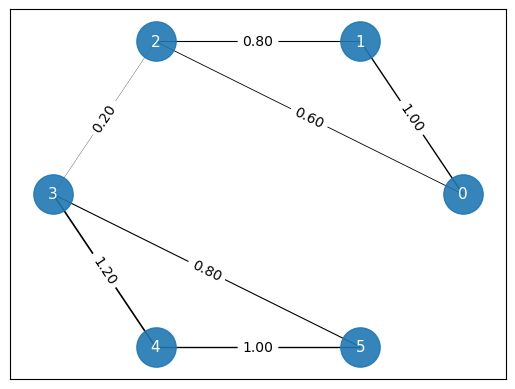

In [4]:
Draw_G_with_edge_weights(G)

We'll check that we can find the obvious communities

In [5]:
G_comms = louvain_communities(G, weight="weight", resolution=1.0, seed=1)
print(G_comms)

[{0, 1, 2}, {3, 4, 5}]


## Compute modularity

For the previous example, let's check the modularity:

In [6]:
modularity(G,G_comms)

0.4585459183673469

Now, let's check a few random examples to make see that there are no better communities there:

In [7]:
c = [{0,1,4},{2,3,5}]; print(f"mod(G,{c})={modularity(G,c)}")
c = [{0,1,2},{3,4},{5}]; print(f"mod(G,{c})={modularity(G,c)}")
c = [{0,1,2,3},{4,5}]; print(f"mod(G,{c})={modularity(G,c)}")

mod(G,[{0, 1, 4}, {2, 3, 5}])=-0.1428571428571429
mod(G,[{0, 1, 2}, {3, 4}, {5}])=0.2633928571428571
mod(G,[{0, 1, 2, 3}, {4, 5}])=0.10204081632653061


## Understanding modularity

The formula for modularity can be written as 
$$Q(G,c)=\frac{1}{2m}\sum_{i=1}^{N}\sum_{j=1}^{N}\left[a_{ij} - \frac{k_{i}k_{j}}{2m}\right]\delta(c_i,c_j)$$
where
* $k_i$ is the sum of the weights on the edges incident to node $i$; it can be useful to denote the vector of such values as $k$,
* $m = \sum_i k_i$
* $A=(a_{ij})$ is the adjency matrix (weighted)
* $\delta_{ij} = 1$ if nodes $i$ and $j$ are in the same cluster/community (slightly different, but equivalent to usual definition)

Note that, $\sum_{i,j}a_{ij} =2m$. Also, let's define a matrix $K=(kk^T)/(2m)$. With a little work you can see that we can think of $K$ as the adjacency matrix of the complete (loopy) graph, $H$, which has the properties:
* $G$ and $H$ have the same set of nodes 
* The (weighted) degree of node $i$ in $H$ is equal to that of node $i$ in $G$.
* The weights of edges incident to node  $i$ are averaged (in so far as possible, while still keeping the same degree.

Here is an example.
First we compute $k$ and $m$

In [8]:
A = nx.to_numpy_array(G, weight="weight")
m = A.sum()/2
k = A.sum(axis=1)
print(f"m={m:6.2f}, k={k}")

m=  5.60, k=[1.6 1.8 1.6 2.2 2.2 1.8]


Let's draw teh graph of this matrix

In [9]:
K = np.outer(k,k)/(2*m)

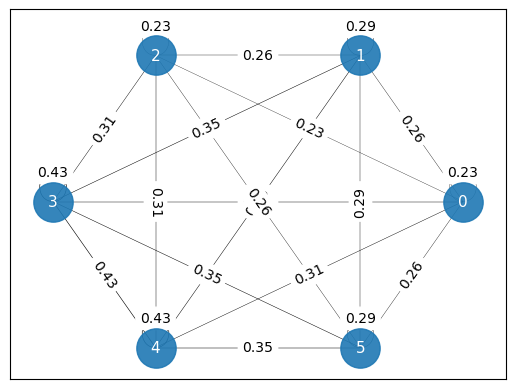

In [10]:
H = nx.from_numpy_array(K)
Draw_G_with_edge_weights(H)

In [11]:
K.sum()/2

np.float64(5.6)

## Modularity form matrix calculations
Next, we note that there is a matrix version of the modularity formula:
$$ 
Q=\frac{1}{2m}\sum_i \sum_j \big( A - K)\circ \Delta\big)_{ij}
$$where $\circ$ denotes entrywise multiplication (also called the Hadamard Product) and $\Delta$ is the matrix whos entries are $\delta_{i,j}$.


This means that, for example, if $G=H$, then $Q=0$ for all $\Delta$.

Let's check that this is correct:

### $\delta$

First, let's consider the $\Delta$ matrix:

In [12]:
def delta_matrix(comms):
    """ Convert a list of commintities to a matrix
    Each community is a set """
    elems = sorted({x for c in comms for x in c}) # c is an individual community
    N = max(elems) + 1
    M = [[0]*N for _ in range(N)]
    for c in comms:
        for i in c:
            for j in c:
                M[i][j] = 1

    return M

In [13]:
p = [{0,1},{2,3}]
Delta = delta_matrix(p)
print(Delta)

[[1, 1, 0, 0], [1, 1, 0, 0], [0, 0, 1, 1], [0, 0, 1, 1]]


### Modularity from matrices
Now we compute the modulatity the matrix way:

In [14]:
def matrix_modularity(G,c):
    A = nx.to_numpy_array(G, weight="weight")
    m = A.sum()/2
    k = A.sum(axis=1)
    K = np.outer(k,k)/(2*m)
    Delta = delta_matrix(c)
    
    return ((A-K)*Delta).sum()/(2*m)

In [15]:
c = [{0,1,4},{2,3,5}]; 
print(f"mod(G,{c})={modularity(G,c)}")
print(f"matrix mod: {matrix_modularity(G,c) }")

mod(G,[{0, 1, 4}, {2, 3, 5}])=-0.1428571428571429
matrix mod: -0.14285714285714285


This shows the two formulations are the same!

## Simple Examples

### Negative modularity

We'll look at the simplest example: a network with just two nodes and one edge:

In [16]:
G1 = nx.Graph()
G1.add_edges_from([(0,1)])

The possible modularites of this graph are:

In [17]:
c = [{0,1}]; print(f"mod(G1,{c})={modularity(G1,c)}") # zero modularity
c = [{0},{1}]; print(f"mod(G1,{c})={modularity(G1,c)}") # negative modularity

mod(G1,[{0, 1}])=0.0
mod(G1,[{0}, {1}])=-0.5


More examples with low modularity

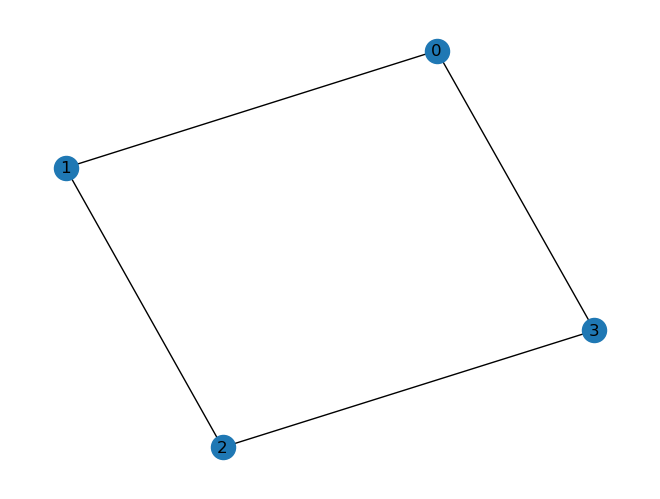

In [18]:
G2 = nx.cycle_graph(4)
nx.draw(G2,with_labels=True)

In [19]:
c = [{0,1,2,3}]; print(f"mod(G2,{c})={modularity(G2,c)}") # zero modularity
c = [{0,1},{2,3}]; print(f"mod(G2,{c})={modularity(G2,c)}") # zero modularity


# negative modularity: because we put non-adjacent nodes in the same community
c = [{0,2},{1,3}]; print(f"mod(G2,{c})={modularity(G2,c)}") 


mod(G2,[{0, 1, 2, 3}])=0.0
mod(G2,[{0, 1}, {2, 3}])=0.0
mod(G2,[{0, 2}, {1, 3}])=-0.5


### Positive Modularity

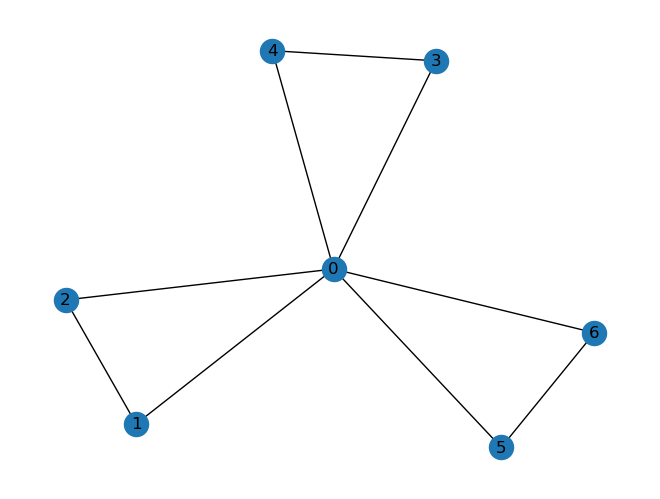

In [20]:
W33 = nx.windmill_graph(3, 3)
nx.draw(W33, with_labels=True)

Compute modularity (no communities). $\delta$ is the identity matrix

In [21]:
c = [{0},{1,2},{3,4}, {5,6}]; print(f"mod(W33,{c})={modularity(W33,c)}") # zero modularity

mod(W33,[{0}, {1, 2}, {3, 4}, {5, 6}])=0.07407407407407407


See what Louvain finds:

In [22]:
W33_comms = louvain_communities(W33, weight="weight", resolution=1.0, seed=1)
print(W33_comms)

[{0, 1, 2}, {3, 4}, {5, 6}]


Let's see if that is better:

In [23]:
print(f"mod(W33,{W33_comms})={modularity(W33, W33_comms)}") 
print(f"mod(W33,{W33_comms})={matrix_modularity(W33, W33_comms)}") 

mod(W33,[{0, 1, 2}, {3, 4}, {5, 6}])=0.14814814814814814
mod(W33,[{0, 1, 2}, {3, 4}, {5, 6}])=0.1481481481481481


## Using Modularity to detect communities

### Exhaustive search

Our first approach will be to check every possible set of communities. That is the set of all partitions of the set $\{0,1,\dots,N-\}$. There are VERY MANY: it is called the Bell Number. It grows like $(n/\log(n))^n$

The following function (written with help from co-pilot) constructs all such partitions.

In [24]:
def set_partitions_list_of_sets(n: int):
    """
    Return all set partitions of {0,1,...,n-1}.
    Each partition is represented as a list of Python sets,
    with blocks ordered by first appearance.
    """
    if n < 0:
        raise ValueError("n must be >= 0")
    if n == 0:
        return [[]]  # the empty partition

    # RGS array a where a[i] is the block index of element i
    a = [0] * n
    # m[i] = max(a[:i]) (prefix max); m[0] = -1, then updated as we advance
    m = [-1] + [0] * n

    result = []
    while True:
        # Build partition from RGS a
        num_blocks = m[n] + 1
        blocks = [set() for _ in range(num_blocks)]
        for i, lab in enumerate(a):
            blocks[lab].add(i)
        result.append(blocks)

        # Next RGS: find rightmost i with a[i] < m[i] + 1; increment and zero suffix
        i = n - 1
        while i >= 1:
            limit = m[i] + 1
            if a[i] < limit:
                a[i] += 1
                mi = a[i] if a[i] > m[i] else m[i]
                m[i + 1] = mi
                # Zero the suffix a[i+1:], and set m[j] = mi for j>i+1
                for j in range(i + 1, n):
                    a[j] = 0
                for j in range(i + 2, n + 1):
                    m[j] = mi
                break
            i -= 1
        else:
            return result

### Example
Let's apply the the Windmill Graph:

In [25]:
N = W33.number_of_nodes()

In [26]:
CommsList = set_partitions_list_of_sets(N)
print(f"There are {len(CommsList)} partitions of {N} indices")

There are 877 partitions of 7 indices


In [27]:
C = CommsList[0]
M_max = 0.0  
i=0
for C in CommsList:
    i+=1
    M_new = modularity(W33, C)
    if (M_new > M_max):
        M_max = M_new
        C_best = C
        print(f"{i:5}: Current best community is {C}; modularity is {M_max}")
print(f"Checked {i} communities" )

    4: Current best community is [{0, 1, 2, 3, 4}, {5, 6}]; modularity is 0.12345679012345673
   34: Current best community is [{0, 1, 2}, {3, 4}, {5, 6}]; modularity is 0.14814814814814814
Checked 877 communities


This seems to agree with the value computed above.

### Apply to Cork North West

Cork North West had the fewest candidates, so it is the easiest to test. I extracted the json data from another notebook:

In [63]:
CNW_json = '{"directed": true, "multigraph": false, "graph": {}, "nodes": [{"id": "Dessie Ellis S.F."}, {"id": "Caroline Conroy G.P."}, {"id": "Ian Croft NON-P."}, {"id": "Niall Fitzgerald NON-P."}, {"id": "Paul McAuliffe F.F."}, {"id": "Andrew Montague LAB."}, {"id": "Conor Reddy S.P.B.P."}, {"id": "Stephen Redmond T.N.P.A.P.N."}, {"id": "Noel Rock F.G."}, {"id": "R\\u00f3is\\u00edn Shortall S.D."}], "links": [{"weight": 0.09, "source": "Dessie Ellis S.F.", "target": "Caroline Conroy G.P."}, {"weight": 0.04, "source": "Dessie Ellis S.F.", "target": "Ian Croft NON-P."}, {"weight": 0.02, "source": "Dessie Ellis S.F.", "target": "Niall Fitzgerald NON-P."}, {"weight": 0.06, "source": "Dessie Ellis S.F.", "target": "Paul McAuliffe F.F."}, {"weight": 0.05, "source": "Dessie Ellis S.F.", "target": "Andrew Montague LAB."}, {"weight": 0.39, "source": "Dessie Ellis S.F.", "target": "Conor Reddy S.P.B.P."}, {"weight": 0.05, "source": "Dessie Ellis S.F.", "target": "Stephen Redmond T.N.P.A.P.N."}, {"weight": 0.02, "source": "Dessie Ellis S.F.", "target": "Noel Rock F.G."}, {"weight": 0.28, "source": "Dessie Ellis S.F.", "target": "R\\u00f3is\\u00edn Shortall S.D."}, {"weight": 0.17, "source": "Caroline Conroy G.P.", "target": "Paul McAuliffe F.F."}, {"weight": 0.4, "source": "Caroline Conroy G.P.", "target": "Conor Reddy S.P.B.P."}, {"weight": 0.25, "source": "Caroline Conroy G.P.", "target": "Noel Rock F.G."}, {"weight": 0.15, "source": "Ian Croft NON-P.", "target": "Caroline Conroy G.P."}, {"weight": 0.05, "source": "Ian Croft NON-P.", "target": "Paul McAuliffe F.F."}, {"weight": 0.08, "source": "Ian Croft NON-P.", "target": "Andrew Montague LAB."}, {"weight": 0.28, "source": "Ian Croft NON-P.", "target": "Conor Reddy S.P.B.P."}, {"weight": 0.11, "source": "Ian Croft NON-P.", "target": "Stephen Redmond T.N.P.A.P.N."}, {"weight": 0.05, "source": "Ian Croft NON-P.", "target": "Noel Rock F.G."}, {"weight": 0.14, "source": "Ian Croft NON-P.", "target": "R\\u00f3is\\u00edn Shortall S.D."}, {"weight": 0.15, "source": "Niall Fitzgerald NON-P.", "target": "Caroline Conroy G.P."}, {"weight": 0.05, "source": "Niall Fitzgerald NON-P.", "target": "Paul McAuliffe F.F."}, {"weight": 0.08, "source": "Niall Fitzgerald NON-P.", "target": "Andrew Montague LAB."}, {"weight": 0.28, "source": "Niall Fitzgerald NON-P.", "target": "Conor Reddy S.P.B.P."}, {"weight": 0.11, "source": "Niall Fitzgerald NON-P.", "target": "Stephen Redmond T.N.P.A.P.N."}, {"weight": 0.05, "source": "Niall Fitzgerald NON-P.", "target": "Noel Rock F.G."}, {"weight": 0.14, "source": "Niall Fitzgerald NON-P.", "target": "R\\u00f3is\\u00edn Shortall S.D."}, {"weight": 0.17, "source": "Andrew Montague LAB.", "target": "Paul McAuliffe F.F."}, {"weight": 0.4, "source": "Andrew Montague LAB.", "target": "Conor Reddy S.P.B.P."}, {"weight": 0.25, "source": "Andrew Montague LAB.", "target": "Noel Rock F.G."}, {"weight": 0.1, "source": "Stephen Redmond T.N.P.A.P.N.", "target": "Caroline Conroy G.P."}, {"weight": 0.14, "source": "Stephen Redmond T.N.P.A.P.N.", "target": "Paul McAuliffe F.F."}, {"weight": 0.04, "source": "Stephen Redmond T.N.P.A.P.N.", "target": "Andrew Montague LAB."}, {"weight": 0.25, "source": "Stephen Redmond T.N.P.A.P.N.", "target": "Conor Reddy S.P.B.P."}, {"weight": 0.02, "source": "Stephen Redmond T.N.P.A.P.N.", "target": "Noel Rock F.G."}, {"weight": 0.19, "source": "Stephen Redmond T.N.P.A.P.N.", "target": "R\\u00f3is\\u00edn Shortall S.D."}, {"weight": 0.5, "source": "Noel Rock F.G.", "target": "Paul McAuliffe F.F."}, {"weight": 0.17, "source": "Noel Rock F.G.", "target": "Conor Reddy S.P.B.P."}]}'

We make the graph, and then make it undirected

/home/niall/miniconda3/envs/mamba/envs/2324-CS319/lib/python3.13/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


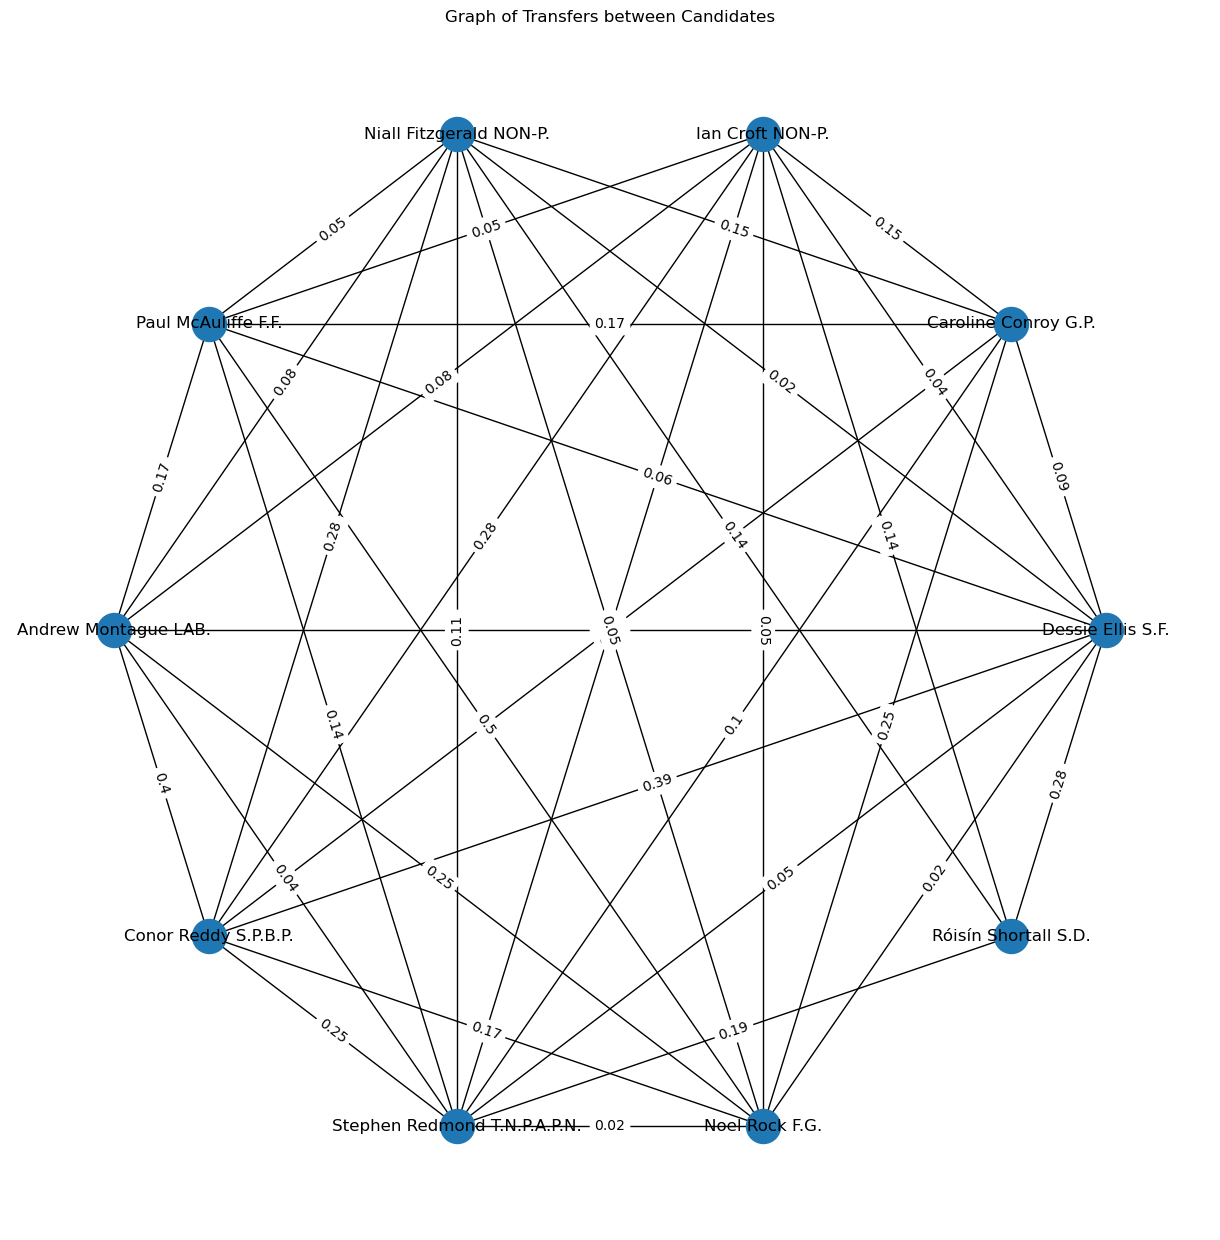

In [64]:
G = nx.node_link_graph(json.loads(CNW_json))
G = G.to_undirected()
plot_G(G)

Check how many potential communities there are

In [65]:
N = G.number_of_nodes()
CommsList = set_partitions_list_of_sets(N)
print(f"There are {len(CommsList)} partitions of {N} indices")

There are 115975 partitions of 10 indices


My search algorithm needs nodes to be labelled 0, 1, 2, etc

In [49]:
old_labels = list(G.nodes())
mapping = {old: i for i, old in enumerate(old_labels)}
G2 = nx.relabel_nodes(G, mapping)

reverse = {i:u for u,i in mapping.items()}

There are only 100,000 to check. Should take just a few seconds

In [66]:
%%time 
C = CommsList[0]
M_max = 0.0  
i=0
for C in CommsList:
    i+=1
    M_new = modularity(G2, C)
    if (M_new > M_max):
        M_max = M_new
        C_best = C
        print(f"{i:5}: Current best community is {C}; modularity is {M_max}")
print(f"Checked {i} communities" )

    7: Current best community is [{0, 1, 2, 3, 4, 5, 6, 8}, {9, 7}]; modularity is 0.019337456334533612
  207: Current best community is [{0, 1, 2, 3, 5, 6, 7, 9}, {8, 4}]; modularity is 0.08316337717651504
  358: Current best community is [{0, 1, 2, 3, 6, 7, 9}, {8, 4, 5}]; modularity is 0.13280909743518884
Checked 115975 communities
CPU times: user 5.39 s, sys: 0 ns, total: 5.39 s
Wall time: 5.38 s


In [68]:
Comm_original = [
    { reverse[i] for i in block }
    for block in C_best
]
print(f"There are {len(Comm_original)} communities")
i=0
for C in Comm_original:
    i+=1
    print(f"Community {i} is {C}\n")

There are 2 communities
Community 1 is {'Dessie Ellis S.F.', 'Stephen Redmond T.N.P.A.P.N.', 'Niall Fitzgerald NON-P.', 'Róisín Shortall S.D.', 'Ian Croft NON-P.', 'Conor Reddy S.P.B.P.', 'Caroline Conroy G.P.'}

Community 2 is {'Noel Rock F.G.', 'Andrew Montague LAB.', 'Paul McAuliffe F.F.'}



Note: the above example is not very senesible. Even if there were one more candidate, this would take far too long. So it is just a way of making sure I/we know what is going on.